In [1]:
!pip install opencv-python tqdm

In [2]:
import cv2
import os
import shutil
from tqdm import tqdm

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import os
import shutil

PROJECT_DIR = "/content/drive/MyDrive/final-year-research"
WORK_DIR = "/content/final-year-research/dataset"
ZIP_PATH = f"{PROJECT_DIR}/dataset/WilderPerson.zip"

os.makedirs(WORK_DIR, exist_ok=True)
shutil.copy(ZIP_PATH, f"{WORK_DIR}/WilderPerson.zip")
print("Copied zip to Colab VM")

Copied zip to Colab VM


In [5]:
import zipfile

with zipfile.ZipFile(f"{WORK_DIR}/WilderPerson.zip", 'r') as zip_ref:
    zip_ref.extractall(f"{WORK_DIR}/dataset")

print("Unzipped dataset")

Unzipped dataset


In [6]:
!ls /content/final-year-research/dataset/

dataset  WilderPerson.zip


In [7]:
!find /content/final-year-research/dataset -maxdepth 3 -type d

/content/final-year-research/dataset
/content/final-year-research/dataset/dataset
/content/final-year-research/dataset/dataset/valid
/content/final-year-research/dataset/dataset/valid/labels
/content/final-year-research/dataset/dataset/valid/images
/content/final-year-research/dataset/dataset/train
/content/final-year-research/dataset/dataset/train/labels
/content/final-year-research/dataset/dataset/train/images


In [ ]:
ORIGINAL_DATASET = "/content/final-year-research/dataset/dataset"
BLUR_DATASET = "/content/final-year-research/dataset/final-year-research_faceblur_WilderPerson"

splits = ["train", "valid"]

In [ ]:
import os

ORIGINAL_DATASET = "/content/final-year-research/dataset/dataset"
splits = ["train", "valid"]

for split in splits:
    print(split)
    print("images exists:", os.path.exists(os.path.join(ORIGINAL_DATASET, split, "images")))
    print("labels exists:", os.path.exists(os.path.join(ORIGINAL_DATASET, split, "labels")))
    print("-" * 30)

train
images exists: True
labels exists: True
------------------------------
valid
images exists: True
labels exists: True
------------------------------


In [ ]:
for split in splits:
    src_labels = os.path.join(ORIGINAL_DATASET, split, "labels")
    dst_labels = os.path.join(BLUR_DATASET, split, "labels")

    os.makedirs(dst_labels, exist_ok=True)

    for file in os.listdir(src_labels):
        shutil.copy(
            os.path.join(src_labels, file),
            os.path.join(dst_labels, file)
        )

print("Labels copied.")

Labels copied.


In [ ]:
face_detector = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
)

In [ ]:
def yolo_to_xyxy(label_line, img_w, img_h):
    parts = label_line.strip().split()
    cls_id, x_center, y_center, width, height = map(float, parts)

    x_center *= img_w
    y_center *= img_h
    width *= img_w
    height *= img_h

    x1 = int(x_center - width / 2)
    y1 = int(y_center - height / 2)
    x2 = int(x_center + width / 2)
    y2 = int(y_center + height / 2)

    x1 = max(0, x1)
    y1 = max(0, y1)
    x2 = min(img_w, x2)
    y2 = min(img_h, y2)

    return int(cls_id), x1, y1, x2, y2

Testing purposes for 1 image

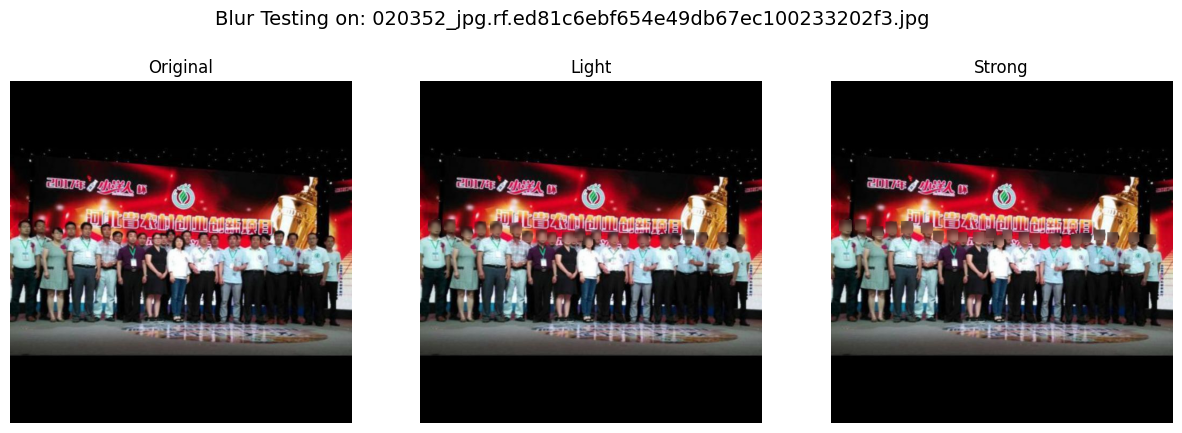

In [ ]:
import os
import cv2
import random
import matplotlib.pyplot as plt

# Path
TRAIN_IMAGES = os.path.join(ORIGINAL_DATASET, "train", "images")
TRAIN_LABELS = os.path.join(ORIGINAL_DATASET, "train", "labels")

# Pick random image
image_files = os.listdir(TRAIN_IMAGES)
img_name = random.choice(image_files)

img_path = os.path.join(TRAIN_IMAGES, img_name)
label_path = os.path.join(TRAIN_LABELS, os.path.splitext(img_name)[0] + ".txt")

# Load image
img = cv2.imread(img_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

img_h, img_w = img.shape[:2]

# Blur levels
blur_settings = {
    "Light": ((15,15), 3),
    "Strong": ((21,21), 6)
}

# Function to apply head-region blur
def apply_blur(image, labels, kernel, sigma):
    img_copy = image.copy()

    for line in labels:
        cls_id, x1, y1, x2, y2 = yolo_to_xyxy(line, img_w, img_h)

        if cls_id != 0:
            continue

        x1 = max(0, x1)
        y1 = max(0, y1)
        x2 = min(img_w, x2)
        y2 = min(img_h, y2)

        person_h = y2 - y1

        if person_h <= 0:
            continue

        # top 35% region
        head_y2 = y1 + int(person_h * 0.75)

        region = img_copy[y1:head_y2, x1:x2]

        if region.size == 0:
            continue

        blurred = cv2.GaussianBlur(region, kernel, sigma)
        img_copy[y1:head_y2, x1:x2] = blurred

    return img_copy

# Read labels
if os.path.exists(label_path):
    with open(label_path, "r") as f:
        labels = f.readlines()
else:
    labels = []

# Apply blur levels
results = {"Original": img_rgb}

for name, (kernel, sigma) in blur_settings.items():
    blurred_img = apply_blur(img, labels, kernel, sigma)
    results[name] = cv2.cvtColor(blurred_img, cv2.COLOR_BGR2RGB)

# Plot results
plt.figure(figsize=(15,5))

for i, (title, image) in enumerate(results.items()):
    plt.subplot(1, len(results), i+1)
    plt.imshow(image)
    plt.title(title)
    plt.axis("off")

plt.suptitle(f"Blur Testing on: {img_name}", fontsize=14)
plt.show()

Face only masked

In [ ]:
BLUR_KERNEL = (21, 21)
BLUR_SIGMA = 6

for split in splits:
    src_images = os.path.join(ORIGINAL_DATASET, split, "images")
    src_labels = os.path.join(ORIGINAL_DATASET, split, "labels")

    dst_images = os.path.join(BLUR_DATASET, split, "images")
    os.makedirs(dst_images, exist_ok=True)

    image_files = os.listdir(src_images)

    for img_name in tqdm(image_files, desc=f"Processing {split}"):
        img_path = os.path.join(src_images, img_name)
        label_path = os.path.join(src_labels, os.path.splitext(img_name)[0] + ".txt")

        img = cv2.imread(img_path)
        if img is None:
            continue

        img_h, img_w = img.shape[:2]

        if not os.path.exists(label_path):
            cv2.imwrite(os.path.join(dst_images, img_name), img)
            continue

        with open(label_path, "r") as f:
            lines = f.readlines()

        for line in lines:
            cls_id, x1, y1, x2, y2 = yolo_to_xyxy(line, img_w, img_h)

            # only process pedestrian class 0
            if cls_id != 0:
                continue

            ped_roi = img[y1:y2, x1:x2]
            if ped_roi.size == 0:
                continue

            ped_gray = cv2.cvtColor(ped_roi, cv2.COLOR_BGR2GRAY)

            faces = face_detector.detectMultiScale(
                ped_gray,
                scaleFactor=1.1,
                minNeighbors=4,
                minSize=(20, 20)
            )

            for (fx, fy, fw, fh) in faces:
                global_x1 = x1 + fx
                global_y1 = y1 + fy
                global_x2 = global_x1 + fw
                global_y2 = global_y1 + fh

                face_region = img[global_y1:global_y2, global_x1:global_x2]
                if face_region.size == 0:
                    continue

                blurred_face = cv2.GaussianBlur(face_region, BLUR_KERNEL, BLUR_SIGMA)
                img[global_y1:global_y2, global_x1:global_x2] = blurred_face

        cv2.imwrite(os.path.join(dst_images, img_name), img)

print("Face-blur dataset created.")

Processing train:  21%|██        | 2133/10098 [00:13<00:51, 155.13it/s]


KeyboardInterrupt: 

Upper Section of Predestrians masked


In [ ]:
BLUR_KERNEL = (21, 21)
BLUR_SIGMA = 6

splits = ["train", "valid"]

for split in splits:

    src_images = os.path.join(ORIGINAL_DATASET, split, "images")
    src_labels = os.path.join(ORIGINAL_DATASET, split, "labels")

    dst_images = os.path.join(BLUR_DATASET, split, "images")
    os.makedirs(dst_images, exist_ok=True)

    image_files = os.listdir(src_images)

    for img_name in tqdm(image_files, desc=f"Processing {split}"):

        img_path = os.path.join(src_images, img_name)
        label_path = os.path.join(src_labels, os.path.splitext(img_name)[0] + ".txt")

        img = cv2.imread(img_path)
        if img is None:
            continue

        img_h, img_w = img.shape[:2]

        # If no label, copy image as-is
        if not os.path.exists(label_path):
            cv2.imwrite(os.path.join(dst_images, img_name), img)
            continue

        with open(label_path, "r") as f:
            lines = f.readlines()

        for line in lines:

            cls_id, x1, y1, x2, y2 = yolo_to_xyxy(line, img_w, img_h)

            # Only pedestrians
            if cls_id != 0:
                continue

            # Clip bounding box
            x1 = max(0, x1)
            y1 = max(0, y1)
            x2 = min(img_w, x2)
            y2 = min(img_h, y2)

            person_h = y2 - y1
            person_w = x2 - x1

            if person_h <= 0 or person_w <= 0:
                continue

            # Blur top 35% (head region)
            head_y2 = y1 + int(person_h * 0.70)

            face_region = img[y1:head_y2, x1:x2]

            if face_region.size == 0:
                continue

            blurred_face = cv2.GaussianBlur(face_region, BLUR_KERNEL, BLUR_SIGMA)

            img[y1:head_y2, x1:x2] = blurred_face

        cv2.imwrite(os.path.join(dst_images, img_name), img)

print("Face-blur dataset created.")

Processing train:   7%|▋         | 739/10098 [00:04<00:59, 156.91it/s]


KeyboardInterrupt: 

Gaussian Blur

In [ ]:
import shutil

BLUR_KERNEL = (21, 21)
BLUR_SIGMA = 6

splits = ["train", "valid"]

for split in splits:

    src_images = os.path.join(ORIGINAL_DATASET, split, "images")
    src_labels = os.path.join(ORIGINAL_DATASET, split, "labels")

    dst_images = os.path.join(BLUR_DATASET, split, "images")
    dst_labels = os.path.join(BLUR_DATASET, split, "labels")

    os.makedirs(dst_images, exist_ok=True)
    os.makedirs(dst_labels, exist_ok=True)

    image_files = os.listdir(src_images)

    for img_name in tqdm(image_files, desc=f"Processing {split}"):

        img_path = os.path.join(src_images, img_name)
        label_name = os.path.splitext(img_name)[0] + ".txt"
        label_path = os.path.join(src_labels, label_name)

        img = cv2.imread(img_path)
        if img is None:
            continue

        img_h, img_w = img.shape[:2]

        if not os.path.exists(label_path):
            cv2.imwrite(os.path.join(dst_images, img_name), img)
            continue

        # copy labels
        shutil.copy(label_path, os.path.join(dst_labels, label_name))

        with open(label_path, "r") as f:
            lines = f.readlines()

        for line in lines:

            cls_id, x1, y1, x2, y2 = yolo_to_xyxy(line, img_w, img_h)

            if cls_id != 0:
                continue

            x1 = max(0, x1)
            y1 = max(0, y1)
            x2 = min(img_w, x2)
            y2 = min(img_h, y2)

            person_h = y2 - y1

            if person_h <= 0:
                continue


            head_y2 = y1 + int(person_h * 0.75)

            face_region = img[y1:head_y2, x1:x2]

            if face_region.size == 0:
                continue

            blurred_face = cv2.GaussianBlur(face_region, BLUR_KERNEL, BLUR_SIGMA)
            img[y1:head_y2, x1:x2] = blurred_face

        cv2.imwrite(os.path.join(dst_images, img_name), img)

print("Head-region Gaussian blur dataset created.")

Processing valid: 100%|██████████| 3284/3284 [00:24<00:00, 133.34it/s]

Head-region Gaussian blur dataset created.


In [ ]:
for split in splits:
    print(f"\n{split.upper()}")
    print("images:", len(os.listdir(os.path.join(BLUR_DATASET, split, "images"))))
    print("labels:", len(os.listdir(os.path.join(BLUR_DATASET, split, "labels"))))


TRAIN
images: 10098
labels: 10098

VALID
images: 3284
labels: 3284


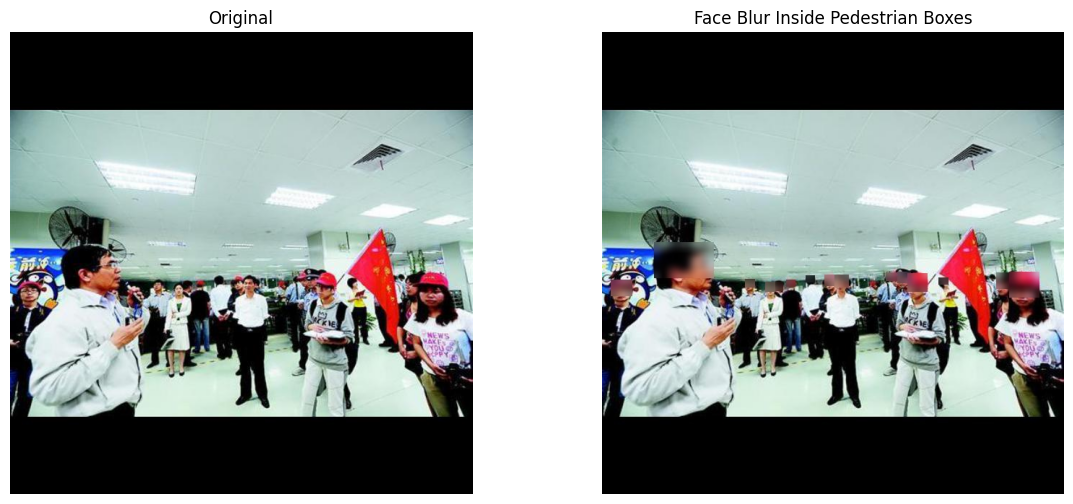

In [ ]:
import matplotlib.pyplot as plt

import random

split = "train"
sample_img = random.choice(os.listdir(os.path.join(ORIGINAL_DATASET, split, "images")))

orig_path = os.path.join(ORIGINAL_DATASET, split, "images", sample_img)
blur_path = os.path.join(BLUR_DATASET, split, "images", sample_img)

orig = cv2.cvtColor(cv2.imread(orig_path), cv2.COLOR_BGR2RGB)
blur = cv2.cvtColor(cv2.imread(blur_path), cv2.COLOR_BGR2RGB)

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.imshow(orig)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(blur)
plt.title("Face Blur Inside Pedestrian Boxes")
plt.axis("off")

plt.show()

Save the Transformed dataset

In [ ]:
import shutil
import os

SRC = "/content/final-year-research/dataset/final-year-research_faceblur_WilderPerson"
DST = "/content/drive/MyDrive/final-year-research/datasets/strong_gaussian_faceblur_dataset"

# remove old version if it exists
if os.path.exists(DST):
    shutil.rmtree(DST)

shutil.copytree(SRC, DST)

print("Blur dataset saved to Google Drive:", DST)

Blur dataset saved to Google Drive: /content/drive/MyDrive/final-year-research/datasets/strong_gaussian_faceblur_dataset


In [ ]:
import shutil

shutil.make_archive(
    "/content/drive/MyDrive/final-year-research/datasets/gaussian_faceblur_dataset",
    "zip",
    "/content/drive/MyDrive/final-year-research/datasets/gaussian_faceblur_dataset"
)

print("Dataset zipped and saved to Drive")

Dataset zipped and saved to Drive


Use the Below Code for training later

In [ ]:
import yaml

data = {
    "path": "/content/drive/MyDrive/final-year-research/datasets/faceblur_dataset",
    "train": "train/images",
    "val": "valid/images",
    "names": {0: "ped"}
}

with open("/content/faceblur.yaml", "w") as f:
    yaml.dump(data, f)

print("YAML file created")

In [ ]:
!yolo detect train \
model=yolov8n.pt \
data="/content/faceblur.yaml" \
epochs=50 \
imgsz=640 \
batch=16 \
device=0 \
project="/content/drive/MyDrive/final-year-research/outputs" \
name="faceblur_run"

# **Pixelation of Dataset**

In [8]:
ORIGINAL_DATASET = "/content/final-year-research/dataset/dataset"
PIXELATED_DATASET = "/content/final-year-research/dataset/final-year-research_pixelated_WilderPerson"

splits = ["train", "valid"]

In [9]:
import os

ORIGINAL_DATASET = "/content/final-year-research/dataset/dataset"
splits = ["train", "valid"]

for split in splits:
    print(split)
    print("images exists:", os.path.exists(os.path.join(ORIGINAL_DATASET, split, "images")))
    print("labels exists:", os.path.exists(os.path.join(ORIGINAL_DATASET, split, "labels")))
    print("-" * 30)

train
images exists: True
labels exists: True
------------------------------
valid
images exists: True
labels exists: True
------------------------------


In [ ]:
for split in splits:
    src_labels = os.path.join(ORIGINAL_DATASET, split, "labels")
    dst_labels = os.path.join(BLUR_DATASET, split, "labels")

    os.makedirs(dst_labels, exist_ok=True)

    for file in os.listdir(src_labels):
        shutil.copy(
            os.path.join(src_labels, file),
            os.path.join(dst_labels, file)
        )

print("Labels copied.")

TEsting for 1 image

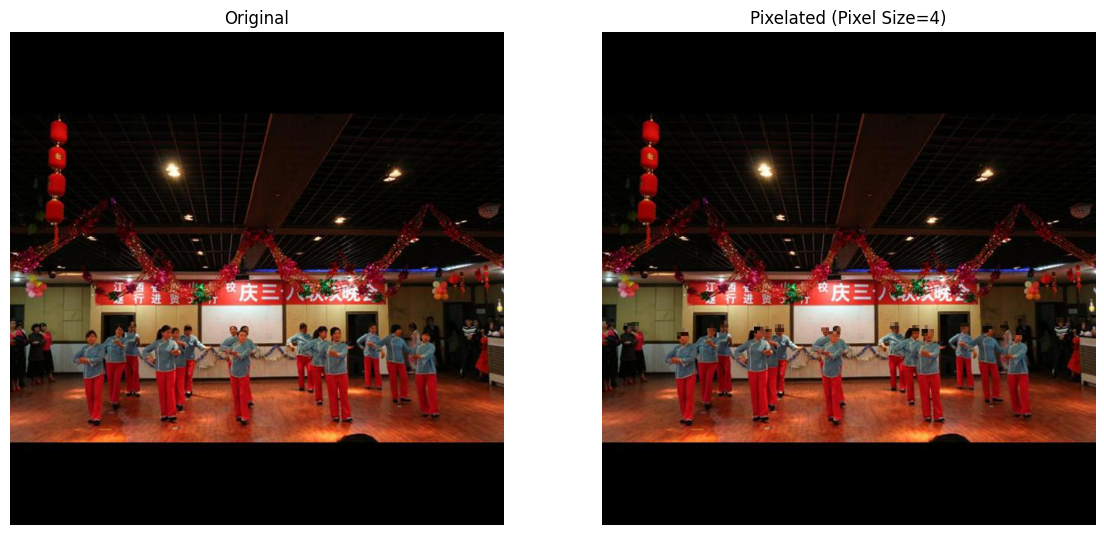

Image: 010670_jpg.rf.8d703463af6fa32fc923df588b03712a.jpg


In [36]:
import os
import cv2
import random
import matplotlib.pyplot as plt

PIXEL_SIZE = 4

# Path
TRAIN_IMAGES = os.path.join(ORIGINAL_DATASET, "train", "images")
TRAIN_LABELS = os.path.join(ORIGINAL_DATASET, "train", "labels")

# Pick random image
image_files = os.listdir(TRAIN_IMAGES)
img_name = random.choice(image_files)

img_path = os.path.join(TRAIN_IMAGES, img_name)
label_path = os.path.join(
    TRAIN_LABELS,
    os.path.splitext(img_name)[0] + ".txt"
)

# Load image
img = cv2.imread(img_path)
original = cv2.cvtColor(img.copy(), cv2.COLOR_BGR2RGB)

img_h, img_w = img.shape[:2]

# YOLO -> XYXY converter
def yolo_to_xyxy(label_line, img_w, img_h):
    cls, x, y, w, h = map(float, label_line.split())

    x *= img_w
    y *= img_h
    w *= img_w
    h *= img_h

    x1 = int(x - w / 2)
    y1 = int(y - h / 2)
    x2 = int(x + w / 2)
    y2 = int(y + h / 2)

    return int(cls), x1, y1, x2, y2

# Apply pixelation
if os.path.exists(label_path):

    with open(label_path, "r") as f:
        lines = f.readlines()

    for line in lines:

        cls_id, x1, y1, x2, y2 = yolo_to_xyxy(
            line, img_w, img_h
        )

        if cls_id != 0:
            continue

        x1 = max(0, x1)
        y1 = max(0, y1)
        x2 = min(img_w, x2)
        y2 = min(img_h, y2)

        person_h = y2 - y1

        if person_h <= 0:
            continue

        # Head region
        head_y2 = y1 + int(person_h * 0.75)

        face_region = img[y1:head_y2, x1:x2]

        if face_region.size == 0:
            continue

        h, w = face_region.shape[:2]

        small = cv2.resize(
            face_region,
            (max(1, w // PIXEL_SIZE),
             max(1, h // PIXEL_SIZE)),
            interpolation=cv2.INTER_LINEAR
        )

        pixelated = cv2.resize(
            small,
            (w, h),
            interpolation=cv2.INTER_NEAREST
        )

        img[y1:head_y2, x1:x2] = pixelated

# Convert for display
pixelated_img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Show result
plt.figure(figsize=(14, 7))

plt.subplot(1, 2, 1)
plt.imshow(original)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(pixelated_img)
plt.title(f"Pixelated (Pixel Size={PIXEL_SIZE})")
plt.axis("off")

plt.show()

print("Image:", img_name)

In [37]:
import os
import cv2
import shutil
from tqdm import tqdm

PIXEL_SIZE = 4

PIXEL_DATASET = "/content/final-year-research/citipersons_pixelated"

splits = ["train", "valid"]

def yolo_to_xyxy(label_line, img_w, img_h):
    cls, x, y, w, h = map(float, label_line.split())

    x *= img_w
    y *= img_h
    w *= img_w
    h *= img_h

    x1 = int(x - w / 2)
    y1 = int(y - h / 2)
    x2 = int(x + w / 2)
    y2 = int(y + h / 2)

    return int(cls), x1, y1, x2, y2


for split in splits:

    src_images = os.path.join(ORIGINAL_DATASET, split, "images")
    src_labels = os.path.join(ORIGINAL_DATASET, split, "labels")

    dst_images = os.path.join(PIXEL_DATASET, split, "images")
    dst_labels = os.path.join(PIXEL_DATASET, split, "labels")

    os.makedirs(dst_images, exist_ok=True)
    os.makedirs(dst_labels, exist_ok=True)

    image_files = os.listdir(src_images)

    for img_name in tqdm(image_files, desc=f"Processing {split}"):

        img_path = os.path.join(src_images, img_name)
        label_name = os.path.splitext(img_name)[0] + ".txt"
        label_path = os.path.join(src_labels, label_name)

        img = cv2.imread(img_path)

        if img is None:
            continue

        img_h, img_w = img.shape[:2]

        if not os.path.exists(label_path):
            cv2.imwrite(os.path.join(dst_images, img_name), img)
            continue

        shutil.copy(label_path, os.path.join(dst_labels, label_name))

        with open(label_path, "r") as f:
            lines = f.readlines()

        for line in lines:

            cls_id, x1, y1, x2, y2 = yolo_to_xyxy(
                line, img_w, img_h
            )

            if cls_id != 0:
                continue

            x1 = max(0, x1)
            y1 = max(0, y1)
            x2 = min(img_w, x2)
            y2 = min(img_h, y2)

            person_h = y2 - y1

            if person_h <= 0:
                continue

            head_y2 = y1 + int(person_h * 0.75)

            face_region = img[y1:head_y2, x1:x2]

            if face_region.size == 0:
                continue

            h, w = face_region.shape[:2]

            small = cv2.resize(
                face_region,
                (max(1, w // PIXEL_SIZE), max(1, h // PIXEL_SIZE)),
                interpolation=cv2.INTER_LINEAR
            )

            pixelated = cv2.resize(
                small,
                (w, h),
                interpolation=cv2.INTER_NEAREST
            )

            img[y1:head_y2, x1:x2] = pixelated

        cv2.imwrite(os.path.join(dst_images, img_name), img)

print("Head-region pixelated dataset created.")

Processing valid: 100%|██████████| 3284/3284 [00:23<00:00, 142.65it/s]

Head-region pixelated dataset created.


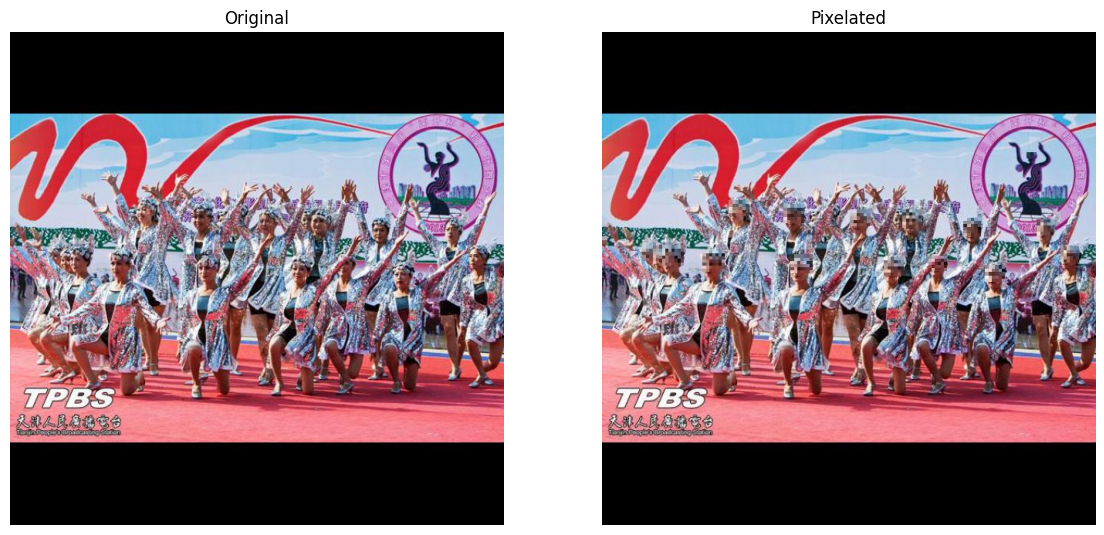

Image: 009962_jpg.rf.170926354d1c13f202bc3129a81e2695.jpg


In [46]:
import os
import cv2
import random
import matplotlib.pyplot as plt

split = "train"

orig_dir = os.path.join(ORIGINAL_DATASET, split, "images")
pixel_dir = os.path.join(PIXEL_DATASET, split, "images")

img_name = random.choice(os.listdir(orig_dir))

orig = cv2.imread(os.path.join(orig_dir, img_name))
pixel = cv2.imread(os.path.join(pixel_dir, img_name))

orig = cv2.cvtColor(orig, cv2.COLOR_BGR2RGB)
pixel = cv2.cvtColor(pixel, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(14, 7))

plt.subplot(1, 2, 1)
plt.imshow(orig)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(pixel)
plt.title("Pixelated")
plt.axis("off")

plt.show()

print("Image:", img_name)

Save the pixelated dataset

In [47]:
import shutil
import os

SRC = "/content/final-year-research/citipersons_pixelated"
DST = "/content/drive/MyDrive/final-year-research/datasets/pixelated_dataset"

# remove old version if it exists
if os.path.exists(DST):
    shutil.rmtree(DST)

shutil.copytree(SRC, DST)

print("Blur dataset saved to Google Drive:", DST)

Blur dataset saved to Google Drive: /content/drive/MyDrive/final-year-research/datasets/pixelated_dataset
